## 1. Import Libraries

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import joblib

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load and Explore Data

In [63]:
df = pd.read_csv('cleaned_combined_posts (2).csv')

print(f"Dataset shape: {df.shape}")
print(f"\nLoaded {len(df)} records from cleaned_combined_posts.csv")
print(f"Viral posts: {df['is_viral'].sum()}")
print(f"Non-viral posts: {(df['is_viral'] == 0).sum()}")
print(f"\nViral percentage: {df['is_viral'].mean()*100:.2f}%")

Dataset shape: (15233, 7)

Loaded 15233 records from cleaned_combined_posts.csv
Viral posts: 3809
Non-viral posts: 11424

Viral percentage: 25.00%


In [64]:
display(df)

,subreddit,title,age_hours,hour-of-day,day-of-week,title_length,is_viral
0,AskReddit,How old were you and how did you find out Sant...,26.857165,16,Wednesday,59,0
1,AskReddit,"In your opinion, what is the best episode of t...",33.621054,9,Wednesday,73,1
2,AskReddit,What do guys “never” tell girls?,34.329943,9,Wednesday,32,1
3,AskReddit,What’s something that instantly gives you “I d...,27.778276,15,Wednesday,77,0
4,AskReddit,What’s the most dangerous thing people do dail...,41.695776,1,Wednesday,69,1
...,...,...,...,...,...,...,...
15228,NoStupidQuestions,My ex stole my cat and got away with it,55.616332,11,Tuesday,39,0
15229,NoStupidQuestions,Least consequential British PM,55.876610,11,Tuesday,30,0
15230,NoStupidQuestions,Anyone else spending more time talking to AI t...,55.896332,11,Tuesday,83,0
15231,NoStupidQuestions,How do people understand that their partner wa...,55.913832,11,Tuesday,90,0


In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15233 entries, 0 to 15232
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   subreddit     15233 non-null  object 
 1   title         15233 non-null  object 
 2   age_hours     15233 non-null  float64
 3   hour-of-day   15233 non-null  int64  
 4   day-of-week   15233 non-null  object 
 5   title_length  15233 non-null  int64  
 6   is_viral      15233 non-null  int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 833.2+ KB


## 3. Exploratory Data Analysis

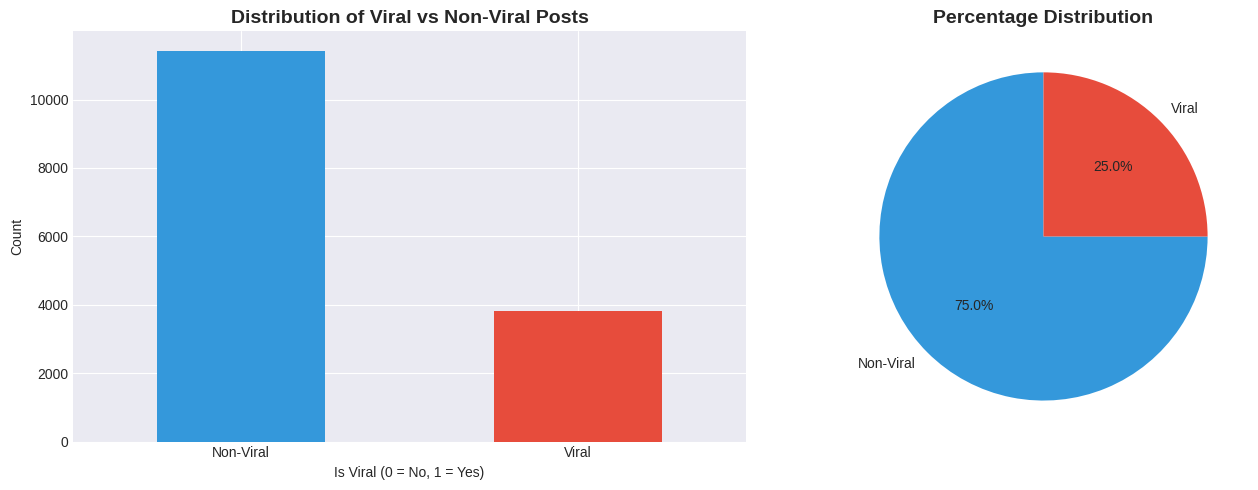

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['is_viral'].value_counts().plot(kind='bar', ax=axes[0], color=['#3498db', '#e74c3c'])
axes[0].set_title('Distribution of Viral vs Non-Viral Posts', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Is Viral (0 = No, 1 = Yes)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Non-Viral', 'Viral'], rotation=0)

df['is_viral'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                                    labels=['Non-Viral', 'Viral'], startangle=90,
                                    colors=['#3498db', '#e74c3c'])
axes[1].set_title('Percentage Distribution', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

/tmp/ipython-input-2487043092.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='is_viral', y='title_length', palette=['#3498db', '#e74c3c'])


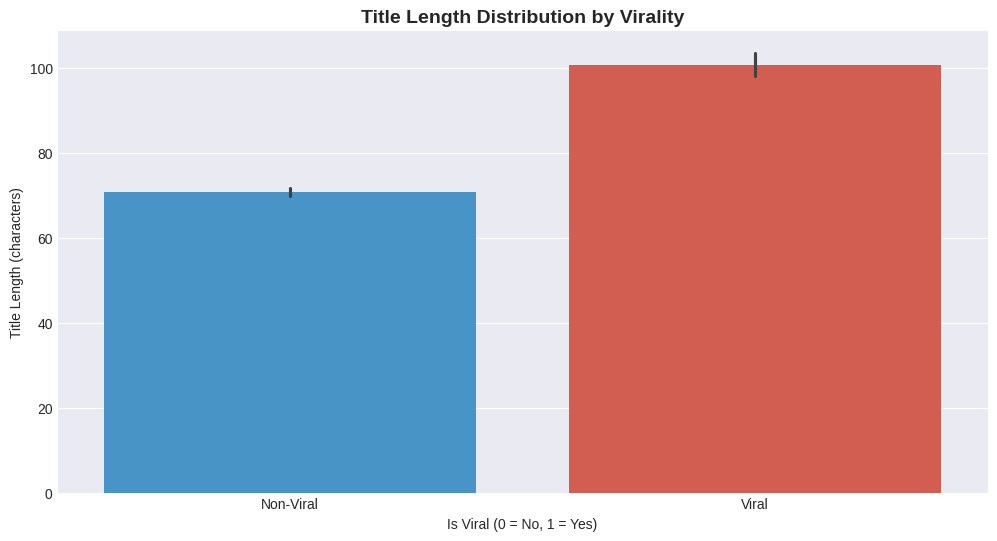

In [67]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='is_viral', y='title_length', palette=['#3498db', '#e74c3c'])
plt.title('Title Length Distribution by Virality', fontsize=14, fontweight='bold')
plt.xlabel('Is Viral (0 = No, 1 = Yes)')
plt.ylabel('Title Length (characters)')
plt.xticks([0, 1], ['Non-Viral', 'Viral'])
plt.show()

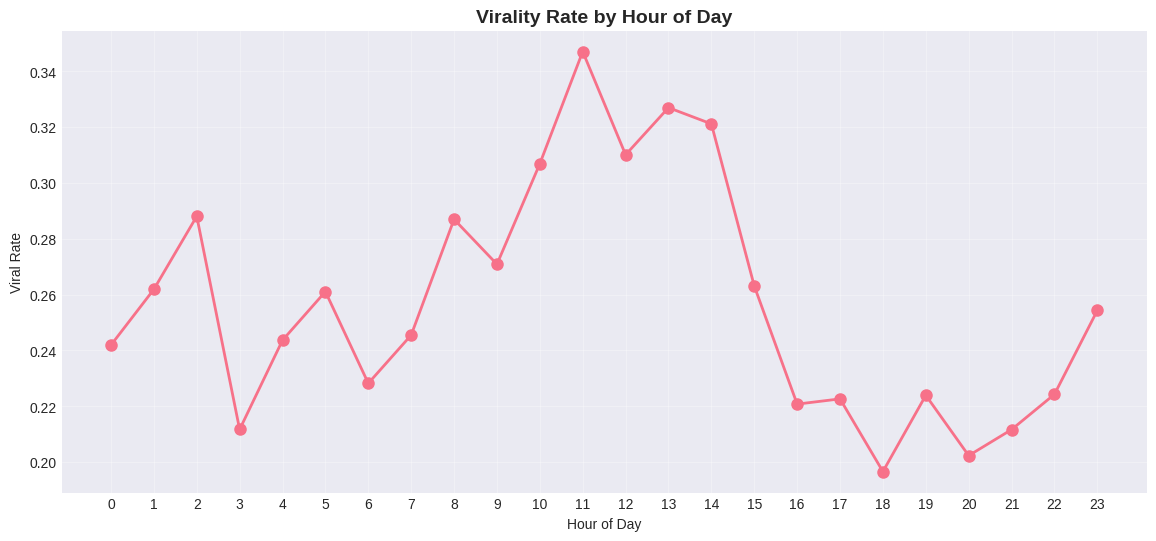

In [68]:
virality_by_hour = df.groupby('hour-of-day')['is_viral'].mean()

plt.figure(figsize=(14, 6))
plt.plot(virality_by_hour.index, virality_by_hour.values, marker='o', linewidth=2, markersize=8)
plt.title('Virality Rate by Hour of Day', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Viral Rate')
plt.grid(True, alpha=0.3)
plt.xticks(range(24))
plt.show()

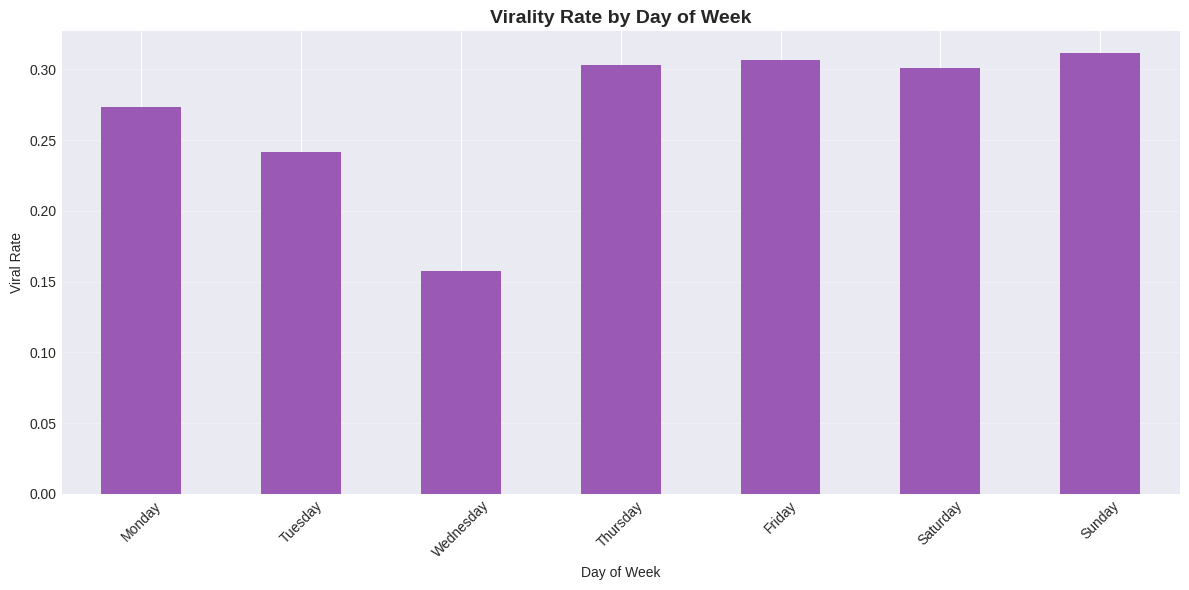

In [69]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
virality_by_day = df.groupby('day-of-week')['is_viral'].mean().reindex(day_order)

plt.figure(figsize=(12, 6))
virality_by_day.plot(kind='bar', color='#9b59b6')
plt.title('Virality Rate by Day of Week', fontsize=14, fontweight='bold')
plt.xlabel('Day of Week')
plt.ylabel('Viral Rate')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

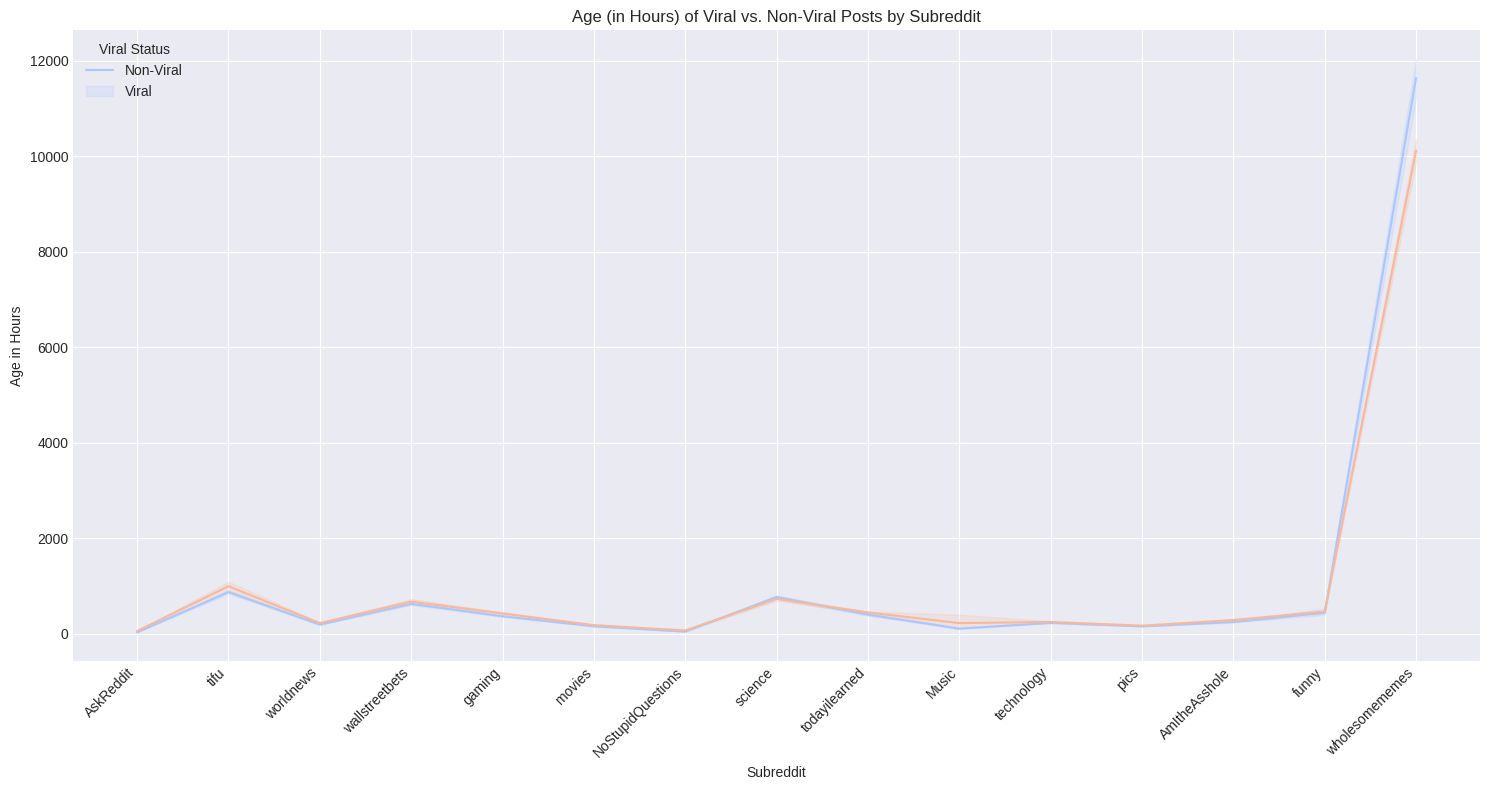

In [70]:
plt.figure(figsize=(15, 8))
sns.lineplot(data=df, x='subreddit', y='age_hours', hue='is_viral', palette='coolwarm')
plt.title('Age (in Hours) of Viral vs. Non-Viral Posts by Subreddit')
plt.xlabel('Subreddit')
plt.ylabel('Age in Hours')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Viral Status', labels=['Non-Viral', 'Viral'])
plt.tight_layout()
plt.show()

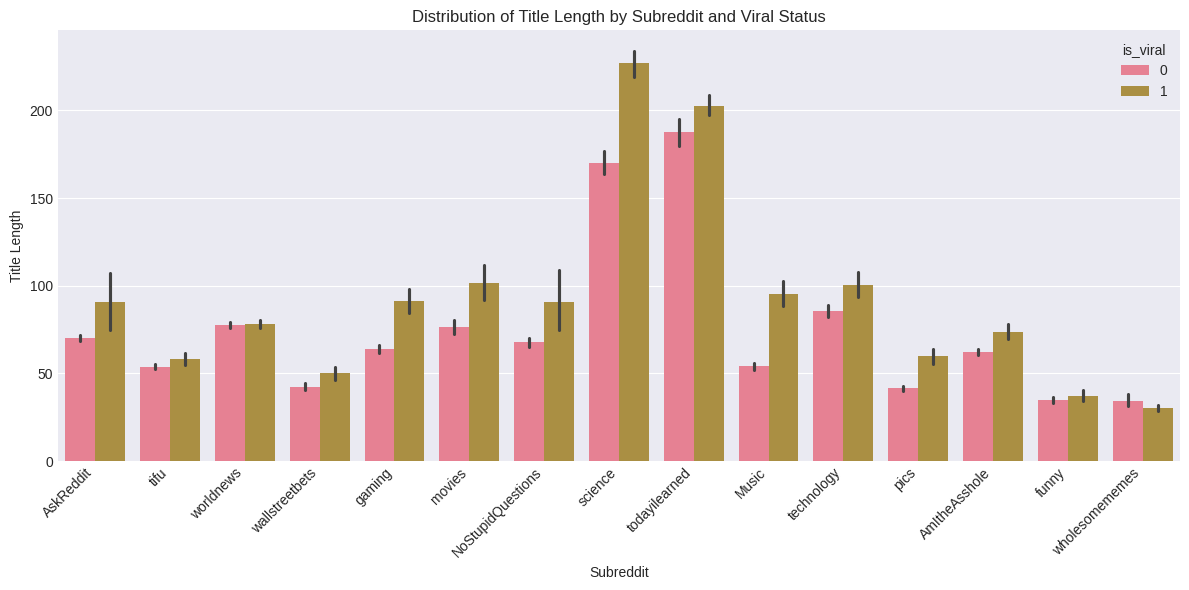

In [104]:
plt.figure(figsize=(12, 6))
sns.barplot(data = df, x= "subreddit",y = "title_length" , hue = "is_viral")
plt.title('Distribution of Title Length by Subreddit and Viral Status')
plt.xlabel('Subreddit')
plt.ylabel('Title Length')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


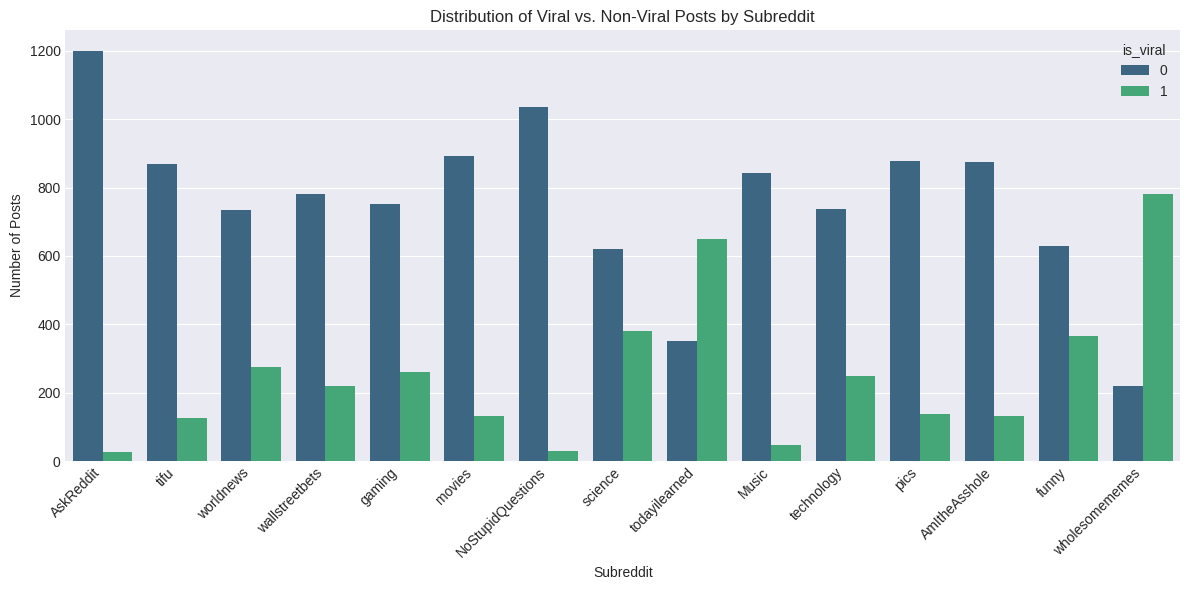

In [105]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='subreddit', hue='is_viral', palette='viridis')
plt.title('Distribution of Viral vs. Non-Viral Posts by Subreddit')
plt.xlabel('Subreddit')
plt.ylabel('Number of Posts')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 4. Feature Engineering

Encode day-of-week

In [72]:
label_encoder = LabelEncoder()
df['day_of_week_encoded'] = label_encoder.fit_transform(df['day-of-week'])

print("Day of week encoding:")
for i, day in enumerate(label_encoder.classes_):
    print(f"{day}: {i}")

Day of week encoding:
Friday: 0
Monday: 1
Saturday: 2
Sunday: 3
Thursday: 4
Tuesday: 5
Wednesday: 6


In [87]:
tfidf = TfidfVectorizer(max_features=2000, stop_words='english')
title_tfidf = tfidf.fit_transform(df['title'].astype(str))
title_tfidf_df = pd.DataFrame(title_tfidf.toarray(),
                              columns=[f'title_tfidf_{i}' for i in range(title_tfidf.shape[1])])

print(f"TF-IDF matrix shape: {title_tfidf_df.shape}")
print(f"Top 10 words by TF-IDF:")
feature_names = tfidf.get_feature_names_out()
print(list(feature_names[:10]))

TF-IDF matrix shape: (15233, 2000)
Top 10 words by TF-IDF:
['000', '0dte', '10', '100', '11', '12', '13', '14', '15', '16']


In [88]:
features_df = pd.concat([
    title_tfidf_df.reset_index(drop=True),
    df[['hour-of-day', 'day_of_week_encoded', 'title_length']].reset_index(drop=True)
], axis=1)


print(f"\nTotal features: {features_df.shape[1]}")
print(f"Feature breakdown:")
print(f"  - TF-IDF features: {title_tfidf_df.shape[1]}")
print(f"  - Other features: {len(feature_columns)}")


Total features: 2003
Feature breakdown:
  - TF-IDF features: 2000
  - Other features: 3


## 5. Train-Test Split

In [89]:
X = features_df
y = df['is_viral']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test set: {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")
print(f"\nTraining set viral rate: {y_train.mean()*100:.2f}%")
print(f"Test set viral rate: {y_test.mean()*100:.2f}%")

Training set: 12186 samples (80.0%)
Test set: 3047 samples (20.0%)

Training set viral rate: 25.00%
Test set viral rate: 25.01%


## 6. Feature Scaling

In [90]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully!")
print(f"Mean of scaled training features: {X_train_scaled.mean():.6f}")
print(f"Std of scaled training features: {X_train_scaled.std():.6f}")

Features scaled successfully!
Mean of scaled training features: 0.000000
Std of scaled training features: 1.000000


## 7. Train Logistic Regression Model

In [96]:
model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model.fit(X_train_scaled, y_train)

print("Model trained successfully!")
print(f"Model coefficients shape: {model.coef_.shape}")
print(f"Model intercept: {model.intercept_[0]:.4f}")

Model trained successfully!
Model coefficients shape: (1, 2003)
Model intercept: -1.0090


## 8. Model Evaluation

In [97]:
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

Accuracy: 0.6620 (66.20%)


In [98]:
print("Classification Report:")
print("="*60)
print(classification_report(y_test, y_pred, target_names=['Non-Viral', 'Viral']))

Classification Report:
              precision    recall  f1-score   support

   Non-Viral       0.83      0.69      0.75      2285
       Viral       0.38      0.56      0.46       762

    accuracy                           0.66      3047
   macro avg       0.60      0.63      0.61      3047
weighted avg       0.72      0.66      0.68      3047



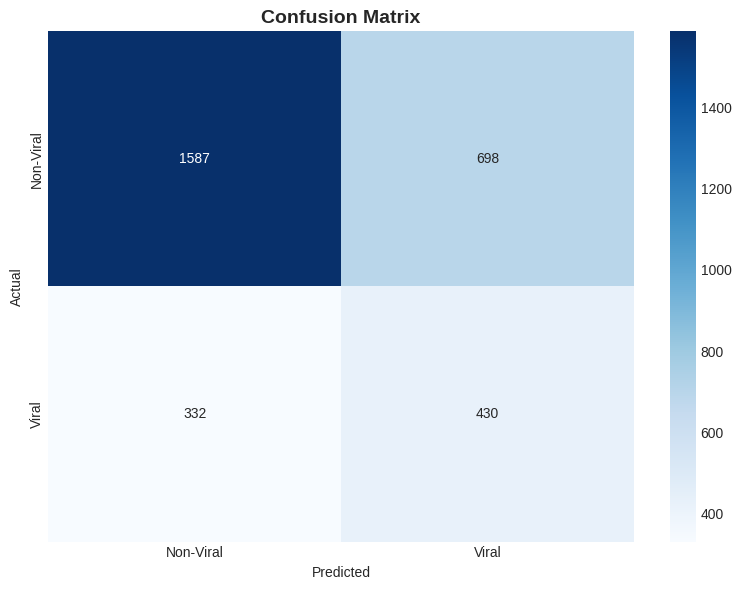


True Negatives: 1587
False Positives: 698
False Negatives: 332
True Positives: 430


In [99]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Non-Viral', 'Viral'],
            yticklabels=['Non-Viral', 'Viral'])
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print(f"\nTrue Negatives: {cm[0,0]}")
print(f"False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}")
print(f"True Positives: {cm[1,1]}")

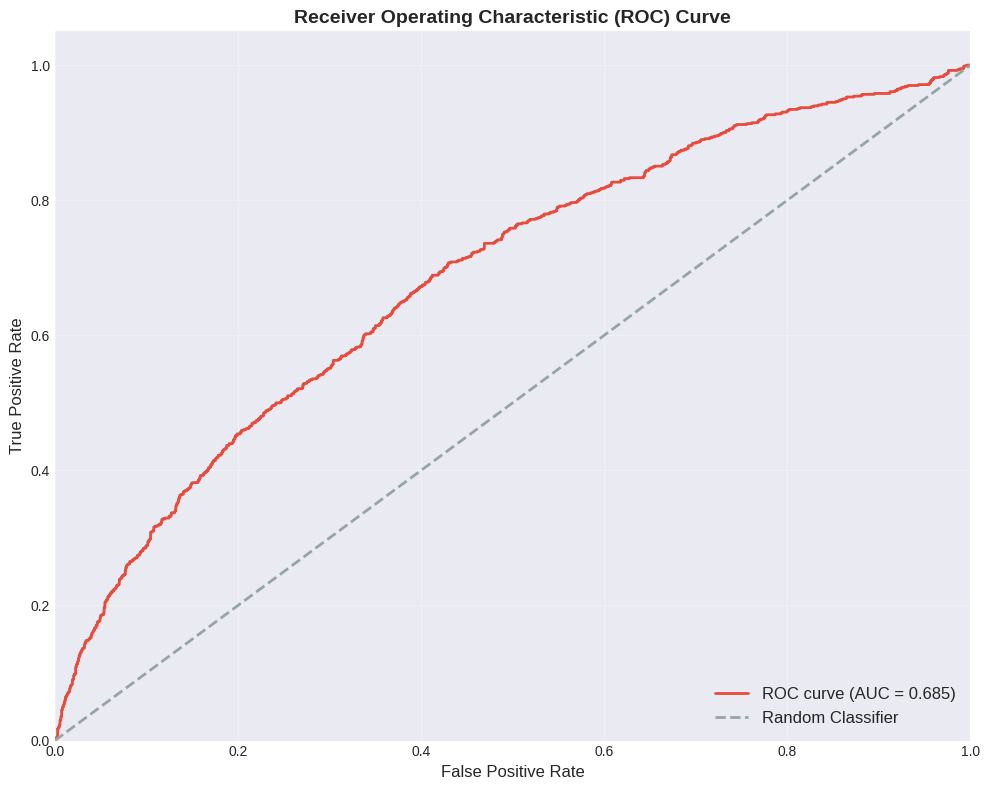

AUC Score: 0.6849


In [95]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='#e74c3c', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='#95a5a6', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC Score: {roc_auc:.4f}")

## 9. Feature Importance Analysis

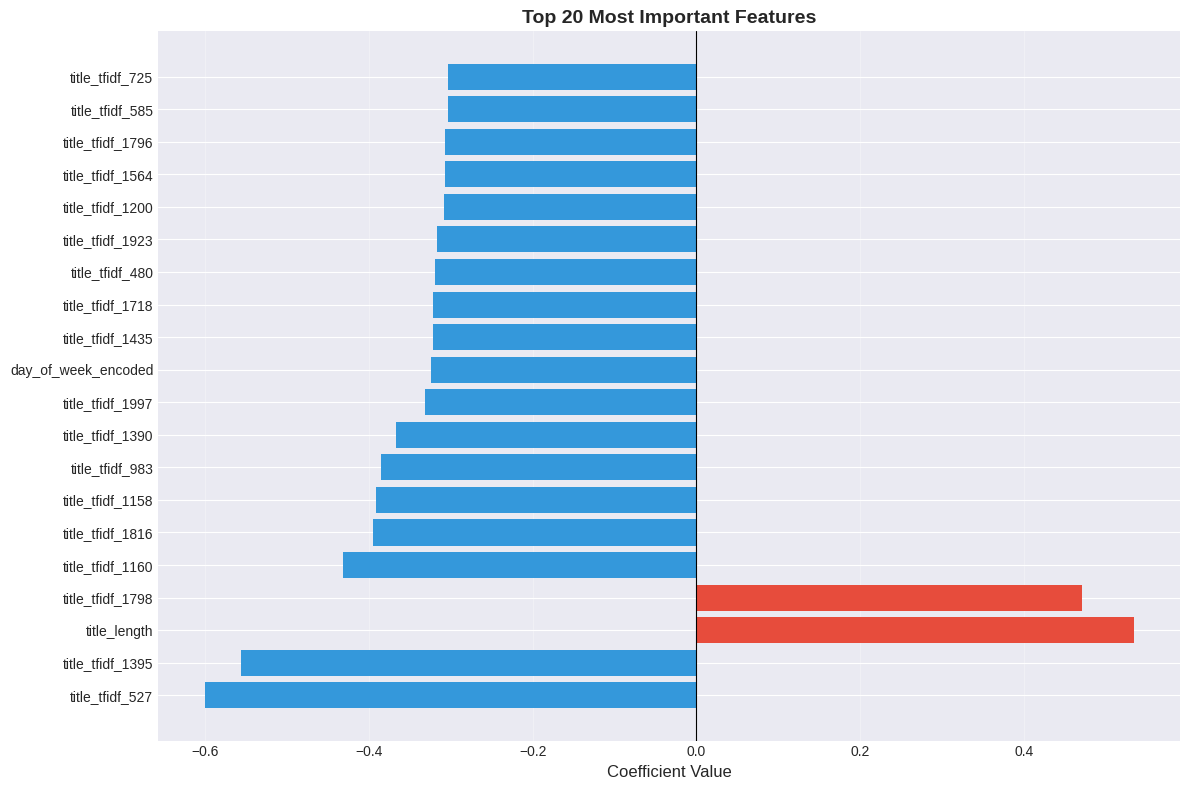

In [100]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_[0]
})
feature_importance['abs_coefficient'] = abs(feature_importance['coefficient'])
feature_importance = feature_importance.sort_values('abs_coefficient', ascending=False)


top_features = feature_importance.head(20)

plt.figure(figsize=(12, 8))
colors = ['#e74c3c' if x > 0 else '#3498db' for x in top_features['coefficient']]
plt.barh(range(len(top_features)), top_features['coefficient'], color=colors)
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Coefficient Value', fontsize=12)
plt.title('Top 20 Most Important Features', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [101]:
non_tfidf_features = feature_importance[~feature_importance['feature'].str.startswith('title_tfidf')]
print("Non-TF-IDF Feature Importance:")
print("="*60)
print(non_tfidf_features.to_string(index=False))

Non-TF-IDF Feature Importance:
            feature  coefficient  abs_coefficient
       title_length     0.534222         0.534222
day_of_week_encoded    -0.324039         0.324039
        hour-of-day    -0.095581         0.095581


## 10. Save Model and Preprocessors

In [102]:
joblib.dump(model, 'logistic_regression_model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
joblib.dump(label_encoder, 'label_encoder.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Model and preprocessors saved successfully!")
print("\nSaved files:")
print("  - logistic_regression_model.pkl")
print("  - tfidf_vectorizer.pkl")
print("  - label_encoder.pkl")
print("  - scaler.pkl")

Model and preprocessors saved successfully!

Saved files:
  - logistic_regression_model.pkl
  - tfidf_vectorizer.pkl
  - label_encoder.pkl
  - scaler.pkl


## 11. Model Summary

In [106]:
print(f"\nDataset:")
print(f"  Total samples: {len(df)}")
print(f"  Training samples: {len(X_train)}")
print(f"  Test samples: {len(X_test)}")
print(f"\nFeatures:")
print(f"  Total features: {X.shape[1]}")
print(f"  TF-IDF features: {title_tfidf_df.shape[1]}")
print(f"  Other features: {len(feature_columns)}")
print(f"\nModel Performance:")
print(f"  Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  AUC Score: {roc_auc:.4f}")
print(f"\nFeatures Used:")
print(f"  - Title (TF-IDF)")
print(f"  - Hour of day")
print(f"  - Day of week")
print(f"  - Title length")



Dataset:
  Total samples: 15233
  Training samples: 12186
  Test samples: 3047

Features:
  Total features: 2003
  TF-IDF features: 2000
  Other features: 3

Model Performance:
  Accuracy: 0.6620 (66.20%)
  AUC Score: 0.6849

Features Used:
  - Title (TF-IDF)
  - Hour of day
  - Day of week
  - Title length
